# 04 - Aplicação estratégica

Transforma a probabilidade de atingir a meta em um ranking de risco municipal e responde às perguntas de negócio sem extrapolar o que a base permite afirmar.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.modeling import FEATURES, carregar_dataset
from src.evaluation import importancia_nativa, perfil_por_regiao, ranking_de_risco

sns.set_theme(style="whitegrid")
df = carregar_dataset()
teste = df[df["ano"] == 2024].copy()
modelo = joblib.load(ROOT / "reports" / "modelo_final.joblib")
ranking = ranking_de_risco(modelo, teste[FEATURES], teste)
display(ranking.head(10))

,id_municipio,ano,sigla_uf,regiao,prob_atingir_meta,prob_risco
0,1712702,2024,TO,Norte,7.015867e-09,1.000000
1,1707702,2024,TO,Norte,2.313474e-08,1.000000
2,1711951,2024,TO,Norte,6.154040e-08,1.000000
3,2203354,2024,PI,Nordeste,2.279486e-07,1.000000
4,2800209,2024,SE,Nordeste,3.386801e-07,1.000000
5,1709807,2024,TO,Norte,4.365150e-07,1.000000
6,2919900,2024,BA,Nordeste,5.119176e-07,0.999999
7,1710706,2024,TO,Norte,5.155928e-07,0.999999
8,1703008,2024,TO,Norte,5.354859e-07,0.999999
9,2805109,2024,SE,Nordeste,5.954374e-07,0.999999


## 1. Quais fatores mais impactam a alfabetização?

Os coeficientes mostram associações do modelo, não causalidade. Variáveis territoriais aparecem em várias dummies; a leitura deve combinar importância e contexto.

In [2]:
importancia = importancia_nativa(modelo)
display(importancia.head(15).round(3))

,variavel,importancia
0,media_portugues,5.416
1,sigla_uf_RN,2.570
2,sigla_uf_PA,2.161
3,sigla_uf_GO,1.970
4,sigla_uf_MS,1.795
5,regiao_Sul,1.659
6,sigla_uf_TO,1.639
7,sigla_uf_AM,1.448
8,sigla_uf_RO,1.379
9,sigla_uf_ES,1.292


## 2. Quais municípios apresentam maior risco educacional?

In [3]:
display(ranking.head(20))
ranking.to_csv(ROOT / "reports" / "ranking_risco_2024.csv", index=False)

,id_municipio,ano,sigla_uf,regiao,prob_atingir_meta,prob_risco
0,1712702,2024,TO,Norte,7.015867e-09,1.000000
1,1707702,2024,TO,Norte,2.313474e-08,1.000000
2,1711951,2024,TO,Norte,6.154040e-08,1.000000
3,2203354,2024,PI,Nordeste,2.279486e-07,1.000000
4,2800209,2024,SE,Nordeste,3.386801e-07,1.000000
5,1709807,2024,TO,Norte,4.365150e-07,1.000000
6,2919900,2024,BA,Nordeste,5.119176e-07,0.999999
7,1710706,2024,TO,Norte,5.155928e-07,0.999999
8,1703008,2024,TO,Norte,5.354859e-07,0.999999
9,2805109,2024,SE,Nordeste,5.954374e-07,0.999999


## 3. Quais regiões possuem padrões semelhantes?

,regiao,municipios,risco_medio
2,Norte,425,0.941
1,Nordeste,1756,0.793
3,Sudeste,1614,0.793
0,Centro-Oeste,464,0.637
4,Sul,1093,0.546


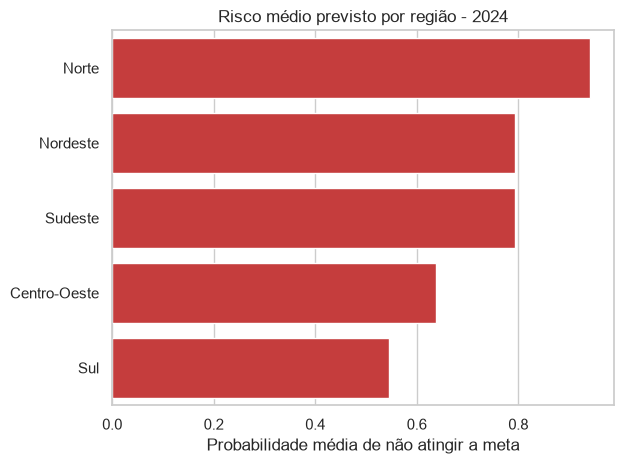

In [4]:
perfil = perfil_por_regiao(ranking)
display(perfil.assign(risco_medio=lambda x: x["risco_medio"].round(3)))
sns.barplot(data=perfil, x="risco_medio", y="regiao", color="#dc2626")
plt.title("Risco médio previsto por região - 2024")
plt.xlabel("Probabilidade média de não atingir a meta")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Como prever municípios que podem não atingir metas futuras?

O ranking prioriza municípios com maior probabilidade de não atingir a meta **no ciclo observado**. Como media_portugues e taxa_media_uf_loo são contemporâneas, esta versão não sustenta uma previsão ex ante de ciclos futuros. Para isso seria necessário defasar as features e dispor de pelo menos três ciclos comparáveis.

In [5]:
for limiar in [0.50, 0.70, 0.80]:
    print(f"Risco >= {limiar:.0%}: {(ranking['prob_risco'] >= limiar).sum():,} municípios")

Risco >= 50%: 4,039 municípios
Risco >= 70%: 3,680 municípios
Risco >= 80%: 3,472 municípios


## 5. Quais variáveis possuem maior influência?

A tabela de importância responde à pergunta dentro do modelo. Ela deve orientar novas investigações, não ser lida como lista de políticas causais.

## Síntese executiva

- Use o ranking para triagem e alocação de atenção técnica, nunca para punição automática.
- Combine probabilidade, contexto regional e capacidade local antes de decidir recursos.
- Monitore drift entre ciclos: a prevalência do alvo muda bastante de 2023 para 2024.
- O próximo passo metodológico é obter novos ciclos e construir features defasadas.